In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

1. Load CIFAR-10 Dataset

In [62]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

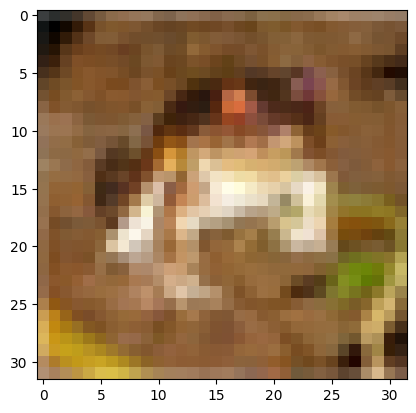

In [3]:
plt.imshow(x_train[0])

In [63]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


2. Define the FFNN Model

In [5]:
def build_ffnn(hidden_layers=[100, 50], activation_fn='relu'):
    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(32, 32, 3)))

    # Hidden layers
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation_fn))

    # Output layer (10 classes for CIFAR-10)
    model.add(layers.Dense(10, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [6]:
history_task1 = {}
history_task2 = {}
models_task1 = {}
models_task2 = {}

In [7]:
def train_and_evaluate(model, model_name, history_dict, model_storage, epochs=10, batch_size=64):
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)

    print(f"{model_name} - Test Accuracy: {test_acc * 100:.2f}%")

    # Store results
    history_dict[model_name] = history.history['val_accuracy']
    model_storage[model_name] = model  # Save trained model

Mini-Task 1: Changing the Number of Hidden Layers

In [8]:
# Different hidden layer configurations
configs_task1 = {
    "FFNN_2_Layers": [100, 75],
    "FFNN_3_Layers": [100, 75, 50],
    "FFNN_5_Layers": [100, 75, 50, 25, 15]
}

# Train models with different hidden layers
for name, h_layer in configs_task1.items():
    model = build_ffnn(hidden_layers=h_layer, activation_fn='relu')
    train_and_evaluate(model, name, history_task1, models_task1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2751 - loss: 2.0188 - val_accuracy: 0.3761 - val_loss: 1.7360
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3821 - loss: 1.7267 - val_accuracy: 0.4090 - val_loss: 1.6544
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4102 - loss: 1.6476 - val_accuracy: 0.4206 - val_loss: 1.6149
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4323 - loss: 1.5870 - val_accuracy: 0.4138 - val_loss: 1.6580
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4417 - loss: 1.5633 - val_accuracy: 0.4214 - val_loss: 1.6116
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4506 - loss: 1.5359 - val_accuracy: 0.4356 - val_loss: 1.5806
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4589 - loss: 1.5134 - val_accuracy: 0.4618 - val_loss: 1.5193
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4655 - loss: 1.4970 - val_accuracy: 0.

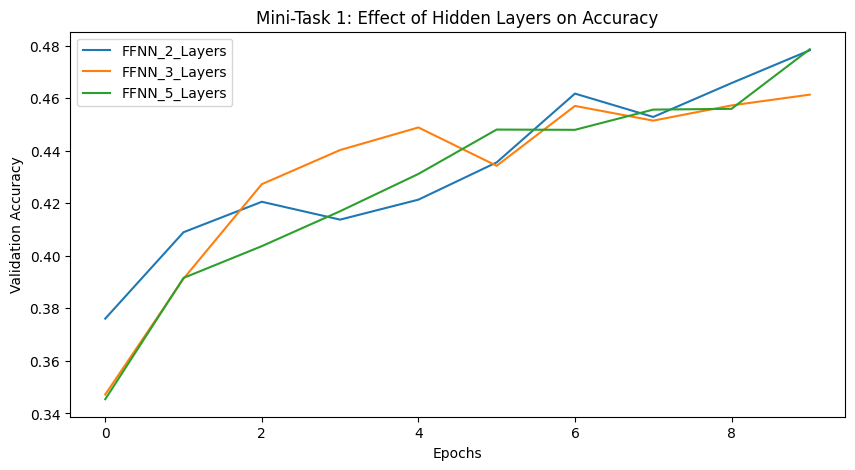

In [9]:
plt.figure(figsize=(10, 5))
for model_name, acc in history_task1.items():
    plt.plot(acc, label=model_name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Mini-Task 1: Effect of Hidden Layers on Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


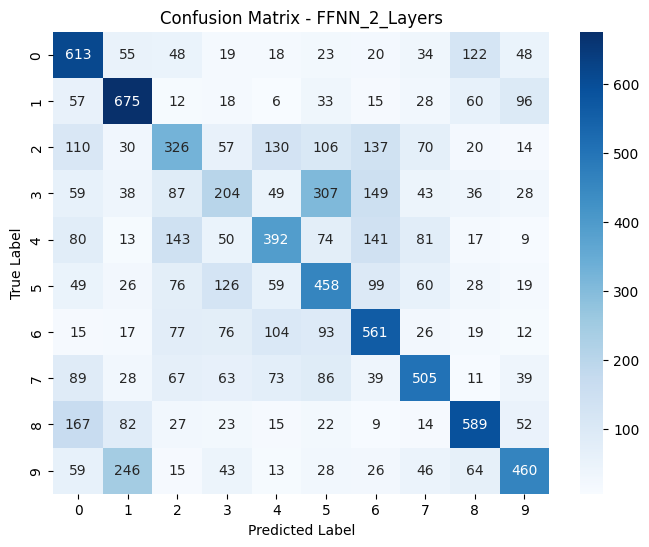

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


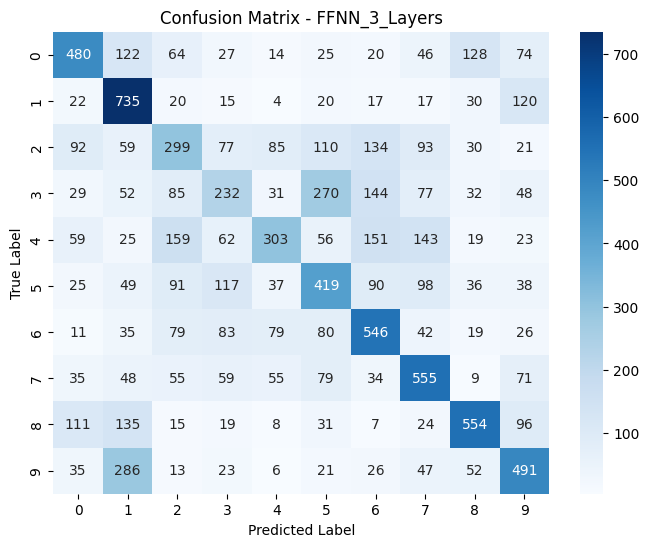

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


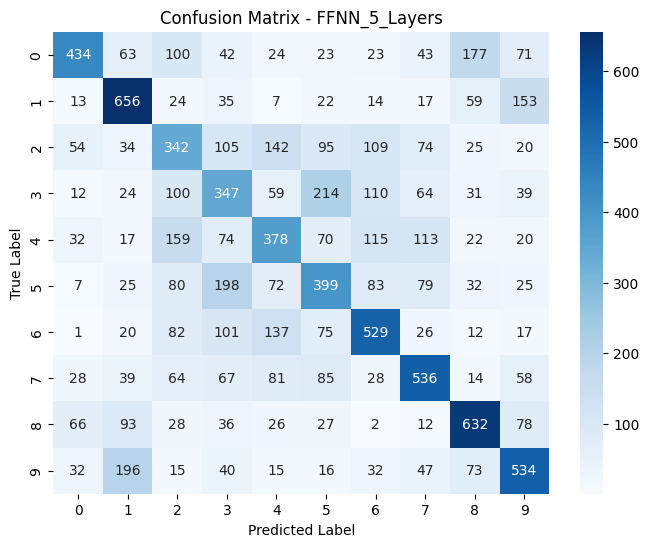

In [12]:
def plot_confusion_matrix(model, model_name):
    y_pred = model.predict(x_test)
    y_pred_classes = y_pred.argmax(axis=1)
    y_true_classes = y_test.argmax(axis=1)

    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Generate confusion matrices for Mini-Task 1
for model_name, model in models_task1.items():
    plot_confusion_matrix(model, model_name)


Mini-Task 2: Experimenting with Different Activation Functions

In [14]:
# Different activation functions
configs_task2 = {
    "FFNN_ReLU": 'relu',
    "FFNN_Sigmoid": 'sigmoid',
    "FFNN_Tanh": 'tanh'
}

# Train models with different activation functions
for name, activation in configs_task2.items():
    model = build_ffnn(hidden_layers=[100, 75], activation_fn=activation)
    train_and_evaluate(model, name, history_task2, models_task2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2776 - loss: 1.9923 - val_accuracy: 0.3644 - val_loss: 1.7770
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3864 - loss: 1.7217 - val_accuracy: 0.3960 - val_loss: 1.6787
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4103 - loss: 1.6510 - val_accuracy: 0.4195 - val_loss: 1.6308
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4272 - loss: 1.6002 - val_accuracy: 0.4247 - val_loss: 1.5975
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4366 - loss: 1.5681 - val_accuracy: 0.4297 - val_loss: 1.5994
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4470 - loss: 1.5333 - val_accuracy: 0.4427 - val_loss: 1.5458
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4568 - loss: 1.5147 - val_accuracy: 0.4662 - val_loss: 1.5109
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4616 - loss: 1.4943 - val_accuracy: 0.

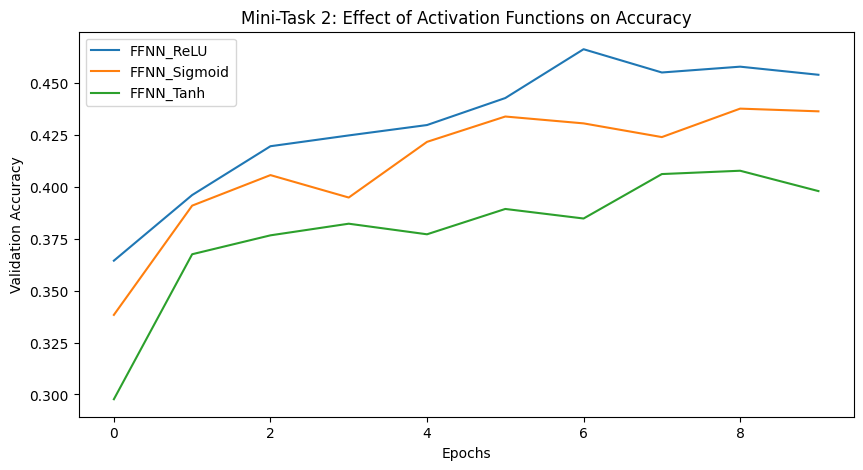

In [15]:
plt.figure(figsize=(10, 5))
for model_name, acc in history_task2.items():
    plt.plot(acc, label=model_name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Mini-Task 2: Effect of Activation Functions on Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


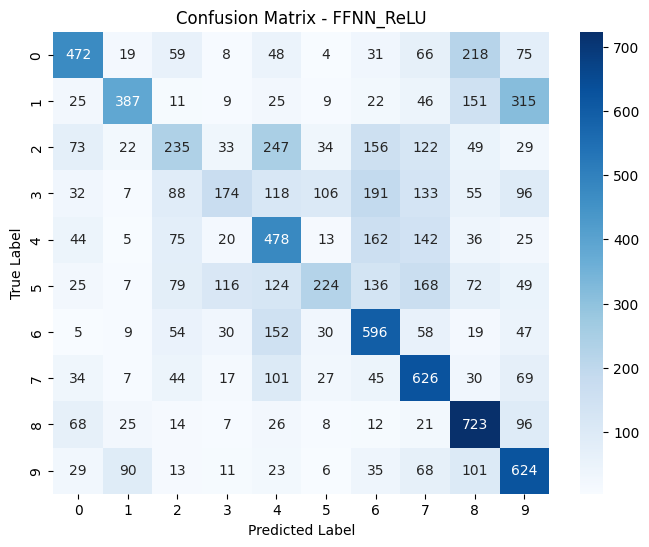

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


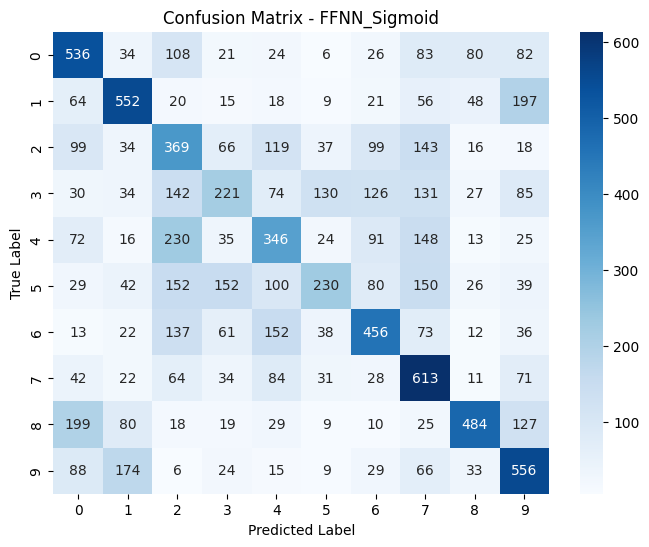

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


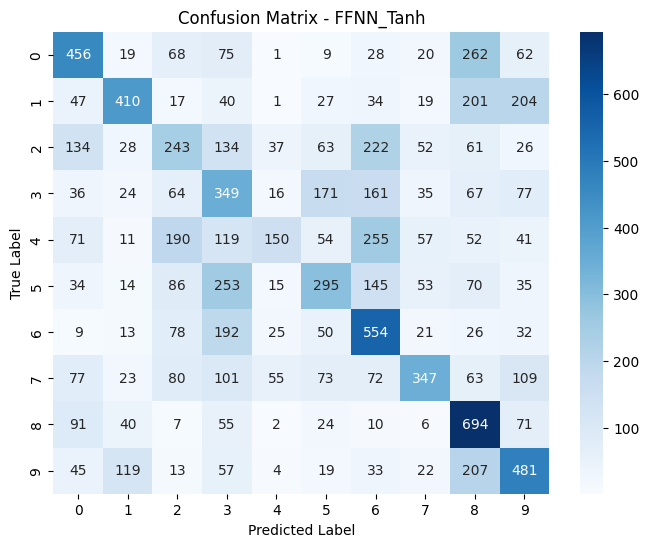

In [16]:
# Generate confusion matrices for Mini-Task 2
for model_name, model in models_task2.items():
    plot_confusion_matrix(model, model_name)


 2. Implement a Basic CNN for CIFAR-10

In [17]:
def build_cnn(pooling_type="max", kernel_size=(3,3)):
    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=kernel_size, activation='relu', input_shape=(32, 32, 3)),
        layers.Conv2D(64, kernel_size=kernel_size, activation='relu'),

        layers.MaxPooling2D(pool_size=(2, 2)) if pooling_type == "max" else layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [18]:
def train_and_evaluate(model, model_name, history_dict, model_storage, epochs=10, batch_size=64):
    print(f"\nTraining {model_name}...\n")

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=2
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n{model_name} - Final Test Accuracy: {test_acc * 100:.2f}%\n")

    history_dict[model_name] = history.history['val_accuracy']
    model_storage[model_name] = model


Train CNN with Max Pooling (Baseline)

In [19]:
history_cnn = {}
models_cnn = {}

cnn_model = build_cnn(pooling_type="max", kernel_size=(3,3))
train_and_evaluate(cnn_model, "CNN_MaxPool_3x3", history_cnn, models_cnn)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN_MaxPool_3x3...

Epoch 1/10
782/782 - 11s - 14ms/step - accuracy: 0.5370 - loss: 1.3136 - val_accuracy: 0.6405 - val_loss: 1.0284
Epoch 2/10
782/782 - 4s - 6ms/step - accuracy: 0.6711 - loss: 0.9421 - val_accuracy: 0.6563 - val_loss: 0.9906
Epoch 3/10
782/782 - 5s - 6ms/step - accuracy: 0.7274 - loss: 0.7809 - val_accuracy: 0.6809 - val_loss: 0.9364
Epoch 4/10
782/782 - 5s - 6ms/step - accuracy: 0.7790 - loss: 0.6361 - val_accuracy: 0.6905 - val_loss: 0.9199
Epoch 5/10
782/782 - 5s - 6ms/step - accuracy: 0.8274 - loss: 0.4992 - val_accuracy: 0.6994 - val_loss: 0.9580
Epoch 6/10
782/782 - 5s - 7ms/step - accuracy: 0.8746 - loss: 0.3683 - val_accuracy: 0.6819 - val_loss: 1.0731
Epoch 7/10
782/782 - 5s - 6ms/step - accuracy: 0.9138 - loss: 0.2551 - val_accuracy: 0.6877 - val_loss: 1.2355
Epoch 8/10
782/782 - 5s - 6ms/step - accuracy: 0.9431 - loss: 0.1692 - val_accuracy: 0.6705 - val_loss: 1.4846
Epoch 9/10
782/782 - 5s - 6ms/step - accuracy: 0.9617 - loss: 0.1176 - val_accur

Mini-Task 3: Replace Max Pooling with Average Pooling

In [20]:
cnn_model_avgpool = build_cnn(pooling_type="avg", kernel_size=(3,3))
train_and_evaluate(cnn_model_avgpool, "CNN_AvgPool_3x3", history_cnn, models_cnn)



Training CNN_AvgPool_3x3...

Epoch 1/10
782/782 - 9s - 12ms/step - accuracy: 0.4865 - loss: 1.4333 - val_accuracy: 0.5820 - val_loss: 1.1850
Epoch 2/10
782/782 - 7s - 9ms/step - accuracy: 0.6253 - loss: 1.0661 - val_accuracy: 0.6335 - val_loss: 1.0500
Epoch 3/10
782/782 - 4s - 5ms/step - accuracy: 0.6877 - loss: 0.8959 - val_accuracy: 0.6505 - val_loss: 0.9952
Epoch 4/10
782/782 - 5s - 7ms/step - accuracy: 0.7268 - loss: 0.7813 - val_accuracy: 0.6774 - val_loss: 0.9336
Epoch 5/10
782/782 - 5s - 6ms/step - accuracy: 0.7658 - loss: 0.6731 - val_accuracy: 0.6758 - val_loss: 0.9583
Epoch 6/10
782/782 - 4s - 5ms/step - accuracy: 0.7992 - loss: 0.5738 - val_accuracy: 0.6836 - val_loss: 0.9597
Epoch 7/10
782/782 - 4s - 5ms/step - accuracy: 0.8360 - loss: 0.4722 - val_accuracy: 0.6796 - val_loss: 1.0539
Epoch 8/10
782/782 - 4s - 5ms/step - accuracy: 0.8664 - loss: 0.3838 - val_accuracy: 0.6755 - val_loss: 1.1152
Epoch 9/10
782/782 - 5s - 7ms/step - accuracy: 0.8980 - loss: 0.2994 - val_accura

Mini-Task 4: Change Kernel Size (3×3 vs. 5×5)

In [21]:
cnn_model_5x5 = build_cnn(pooling_type="max", kernel_size=(5,5))
train_and_evaluate(cnn_model_5x5, "CNN_MaxPool_5x5", history_cnn, models_cnn)



Training CNN_MaxPool_5x5...

Epoch 1/10
782/782 - 10s - 13ms/step - accuracy: 0.4780 - loss: 1.4498 - val_accuracy: 0.5538 - val_loss: 1.2759
Epoch 2/10
782/782 - 4s - 6ms/step - accuracy: 0.6151 - loss: 1.0901 - val_accuracy: 0.6148 - val_loss: 1.0994
Epoch 3/10
782/782 - 4s - 5ms/step - accuracy: 0.6777 - loss: 0.9149 - val_accuracy: 0.6429 - val_loss: 1.0230
Epoch 4/10
782/782 - 5s - 7ms/step - accuracy: 0.7228 - loss: 0.7820 - val_accuracy: 0.6534 - val_loss: 1.0179
Epoch 5/10
782/782 - 4s - 5ms/step - accuracy: 0.7667 - loss: 0.6640 - val_accuracy: 0.6613 - val_loss: 1.0300
Epoch 6/10
782/782 - 4s - 5ms/step - accuracy: 0.8106 - loss: 0.5455 - val_accuracy: 0.6528 - val_loss: 1.0674
Epoch 7/10
782/782 - 4s - 6ms/step - accuracy: 0.8461 - loss: 0.4397 - val_accuracy: 0.6616 - val_loss: 1.1727
Epoch 8/10
782/782 - 4s - 5ms/step - accuracy: 0.8775 - loss: 0.3501 - val_accuracy: 0.6641 - val_loss: 1.2576
Epoch 9/10
782/782 - 5s - 7ms/step - accuracy: 0.9070 - loss: 0.2709 - val_accur

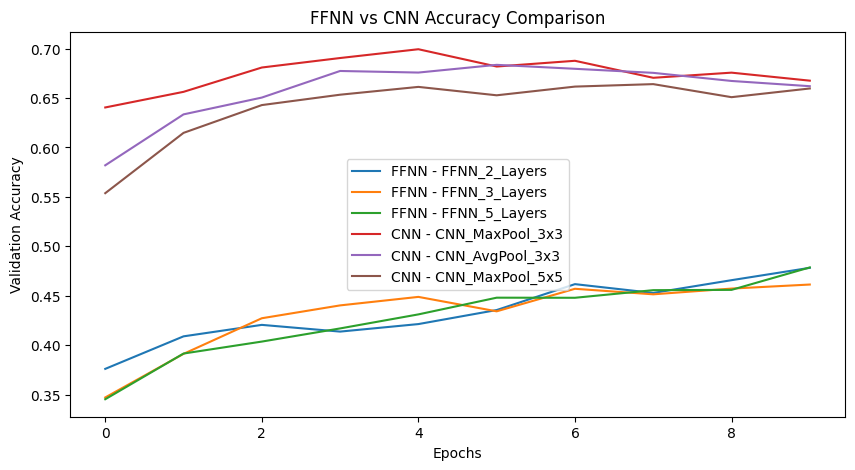

In [22]:
# Combine FFNN and CNN histories
plt.figure(figsize=(10, 5))

# Plot FFNN models
for model_name, acc in history_task1.items():  # FFNN accuracy stored in history_task1
    plt.plot(acc, label=f"FFNN - {model_name}")

# Plot CNN models
for model_name, acc in history_cnn.items():  # CNN accuracy stored in history_cnn
    plt.plot(acc, label=f"CNN - {model_name}")

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('FFNN vs CNN Accuracy Comparison')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


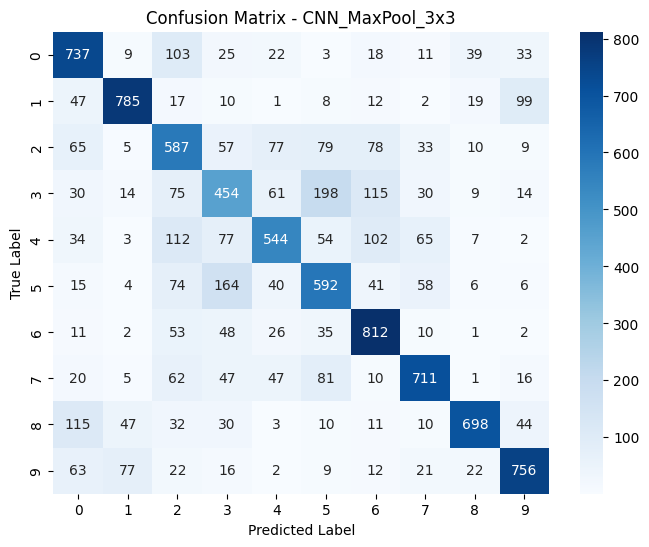

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


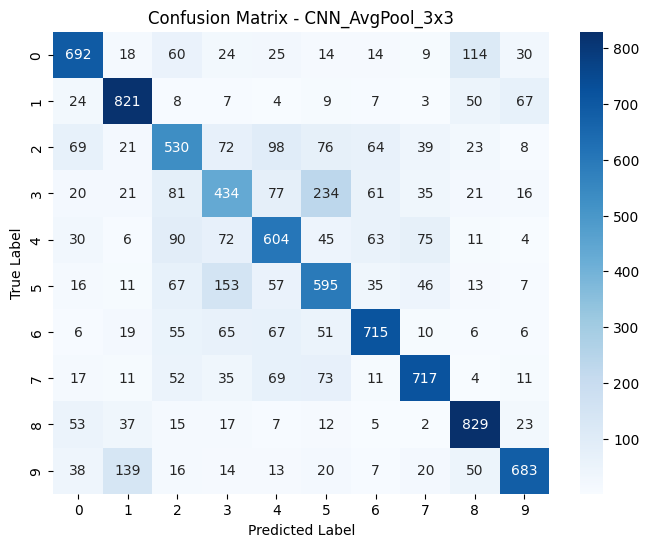

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


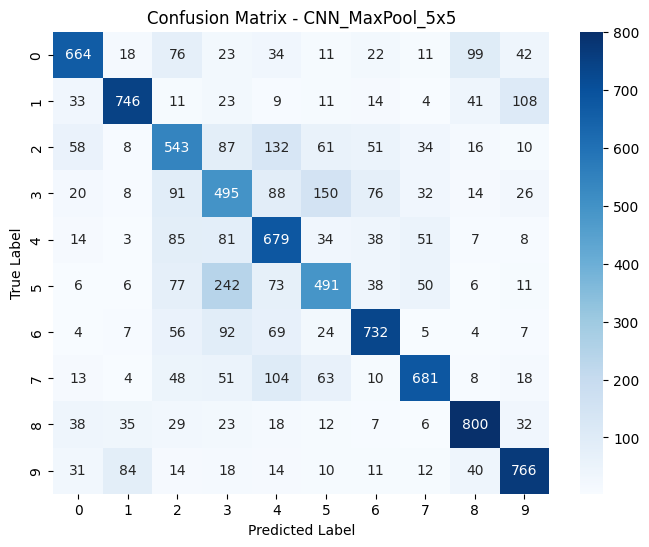

In [23]:
for model_name, model in models_cnn.items():
    plot_confusion_matrix(model, model_name)


Modify CNN with Stride and Padding

In [24]:
def build_cnn2(stride=1, padding="valid"):
    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), strides=stride, padding=padding, activation='relu', input_shape=(32, 32, 3)),
        layers.Conv2D(64, kernel_size=(3, 3), strides=stride, padding=padding, activation='relu'),

        layers.MaxPooling2D(pool_size=(2, 2)),  # Keep pooling fixed for now

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [25]:
history_stride_padding = {}
models_stride_padding = {}

# Baseline: Stride=1, Padding="valid"
cnn_stride1_valid = build_cnn2(stride=1, padding="valid")
train_and_evaluate(cnn_stride1_valid, "Stride1_Valid", history_stride_padding, models_stride_padding)

# Stride=2, Padding="valid"
cnn_stride2_valid = build_cnn2(stride=2, padding="valid")
train_and_evaluate(cnn_stride2_valid, "Stride2_Valid", history_stride_padding, models_stride_padding)

# Stride=1, Padding="same"
cnn_stride1_same = build_cnn2(stride=1, padding="same")
train_and_evaluate(cnn_stride1_same, "Stride1_Same", history_stride_padding, models_stride_padding)

# Stride=2, Padding="same"
cnn_stride2_same = build_cnn2(stride=2, padding="same")
train_and_evaluate(cnn_stride2_same, "Stride2_Same", history_stride_padding, models_stride_padding)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Stride1_Valid...

Epoch 1/10
782/782 - 9s - 12ms/step - accuracy: 0.5057 - loss: 1.3833 - val_accuracy: 0.6085 - val_loss: 1.1054
Epoch 2/10
782/782 - 4s - 6ms/step - accuracy: 0.6488 - loss: 1.0051 - val_accuracy: 0.6572 - val_loss: 0.9789
Epoch 3/10
782/782 - 5s - 6ms/step - accuracy: 0.6963 - loss: 0.8625 - val_accuracy: 0.6656 - val_loss: 0.9531
Epoch 4/10
782/782 - 4s - 5ms/step - accuracy: 0.7380 - loss: 0.7493 - val_accuracy: 0.6724 - val_loss: 0.9468
Epoch 5/10
782/782 - 6s - 7ms/step - accuracy: 0.7750 - loss: 0.6460 - val_accuracy: 0.6761 - val_loss: 0.9613
Epoch 6/10
782/782 - 4s - 6ms/step - accuracy: 0.8080 - loss: 0.5488 - val_accuracy: 0.6834 - val_loss: 0.9831
Epoch 7/10
782/782 - 5s - 6ms/step - accuracy: 0.8421 - loss: 0.4514 - val_accuracy: 0.6845 - val_loss: 1.0320
Epoch 8/10
782/782 - 5s - 6ms/step - accuracy: 0.8781 - loss: 0.3548 - val_accuracy: 0.6772 - val_loss: 1.1641
Epoch 9/10
782/782 - 4s - 6ms/step - accuracy: 0.9046 - loss: 0.2792 - val_accuracy

In [30]:
def print_feature_map_sizes(model, model_name):
    # Generate a dummy CIFAR-10 image (batch size 1)
    dummy_input = np.random.rand(1, 32, 32, 3).astype(np.float32)

    # Run a forward pass to define layer shapes
    model(dummy_input)

    print(f"\nFeature Map Sizes for {model_name}:")
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            print(f"{layer.name}: {layer.output.shape}")

# Call the function after training
for name, model in models_stride_padding.items():
    print_feature_map_sizes(model, name)


Feature Map Sizes for Stride1_Valid:
conv2d_6: (None, 30, 30, 32)
conv2d_7: (None, 28, 28, 64)

Feature Map Sizes for Stride2_Valid:
conv2d_8: (None, 15, 15, 32)
conv2d_9: (None, 7, 7, 64)

Feature Map Sizes for Stride1_Same:
conv2d_10: (None, 32, 32, 32)
conv2d_11: (None, 32, 32, 64)

Feature Map Sizes for Stride2_Same:
conv2d_12: (None, 16, 16, 32)
conv2d_13: (None, 8, 8, 64)


Mini-Task 5: Visualizing Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


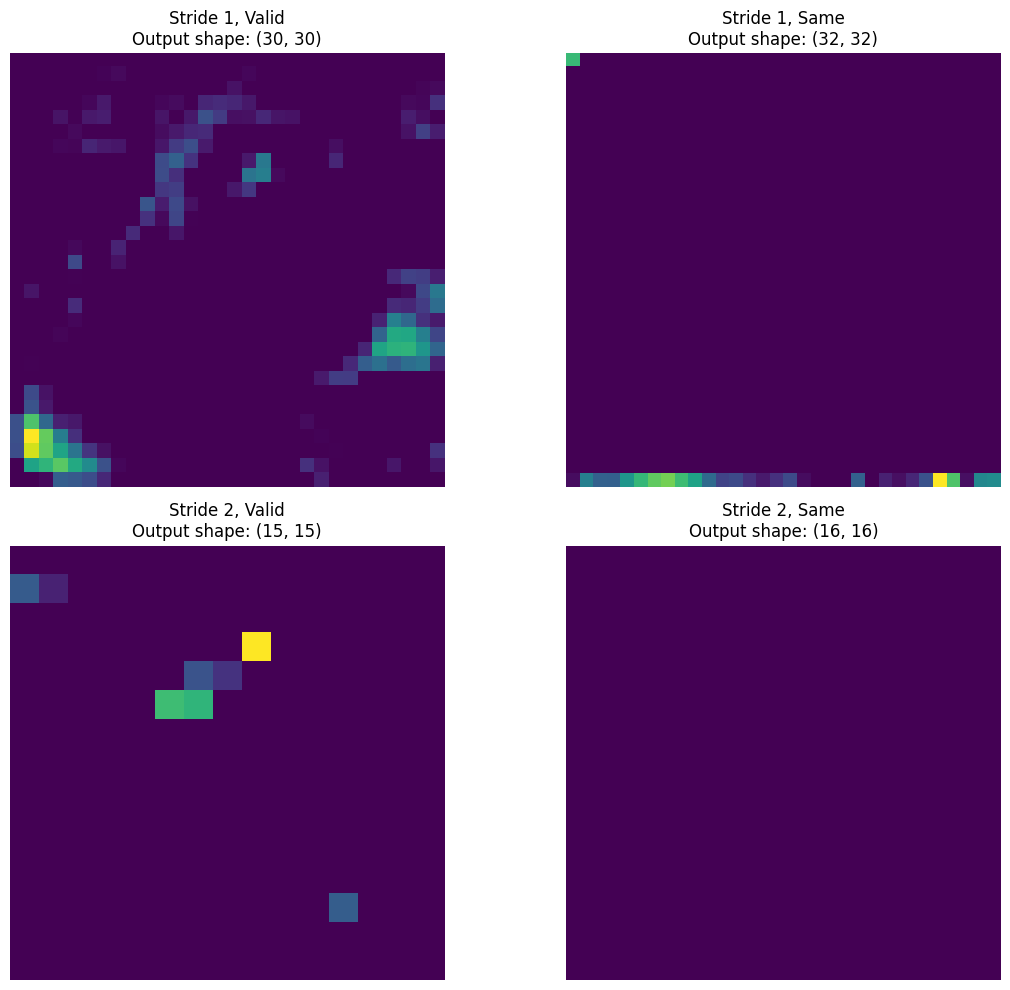

In [48]:
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Model
import numpy as np

# Choose one sample image from the training set (shape: 32x32x3)
sample_img = x_train[0:1]  # shape: (1, 32, 32, 3)

def create_model(stride, padding):
    """
    Creates a simple model with one Conv2D layer.

    Args:
        stride (int): Stride value for the convolution.
        padding (str): Padding type ('valid' or 'same').

    Returns:
        Model: Keras model.
    """
    input_layer = layers.Input(shape=(32, 32, 3))
    # Using 16 filters and a kernel size of 3x3
    conv_layer = layers.Conv2D(filters=16, kernel_size=3, strides=stride, padding=padding, activation='relu')(input_layer)
    model = Model(inputs=input_layer, outputs=conv_layer)
    return model

# Define configurations: different combinations of stride and padding
configs = {
    "Stride 1, Valid": create_model(stride=1, padding='valid'),
    "Stride 1, Same": create_model(stride=1, padding='same'),
    "Stride 2, Valid": create_model(stride=2, padding='valid'),
    "Stride 2, Same": create_model(stride=2, padding='same'),
}

# Visualize the feature maps from each configuration
plt.figure(figsize=(12, 10))
for i, (title, model) in enumerate(configs.items()):
    # Get the feature map by running the sample image through the model
    feature_map = model.predict(sample_img)

    # For visualization, use the first channel of the feature map
    fmap = feature_map[0, :, :, 0]

    # Plot the feature map with the output shape in the title
    plt.subplot(2, 2, i+1)
    plt.imshow(fmap, cmap='viridis')
    plt.title(f"{title}\nOutput shape: {feature_map.shape[1:3]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [64]:
print(y_train.shape, y_test.shape)


(50000, 10) (10000, 10)


In [65]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(50000, 32, 32, 3) (50000, 10)
(10000, 32, 32, 3) (10000, 10)


 Enhance CNN Model with Regularization

Training Baseline (No Dropout, No Augmentation)...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5175 - loss: 1.7915 - val_accuracy: 0.6457 - val_loss: 1.4999
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7201 - loss: 1.1261 - val_accuracy: 0.6230 - val_loss: 1.4673
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7721 - loss: 0.9573 - val_accuracy: 0.7281 - val_loss: 1.1617
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8080 - loss: 0.8923 - val_accuracy: 0.7437 - val_loss: 1.1035
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8309 - loss: 0.8475 - val_accuracy: 0.7067 - val_loss: 1.2350
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8496 - loss: 0.8159 - val_accuracy: 0.7461 - val_loss: 1.1547
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8635 - loss: 0.7963 - val_accuracy: 0.7120 - val_loss: 1.3097
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/

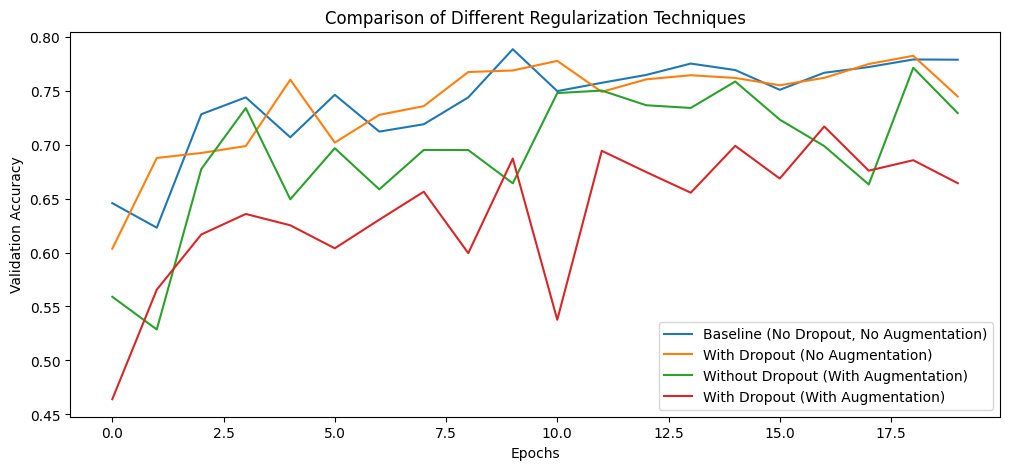

In [68]:
from keras import regularizers, models
from keras import preprocessing
import matplotlib.pyplot as plt


# Data Augmentation
augmentor = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
augmentor.fit(x_train)

# Function to create CNN model
def create_cnn(use_dropout=False, use_augmentation=False):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(0.001), input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Training models
models_to_train = {
    "Baseline (No Dropout, No Augmentation)": (False, False),
    "With Dropout (No Augmentation)": (True, False),
    "Without Dropout (With Augmentation)": (False, True),
    "With Dropout (With Augmentation)": (True, True)
}

histories = {}
for name, (use_dropout, use_augmentation) in models_to_train.items():
    print(f"Training {name}...")
    model = create_cnn(use_dropout=use_dropout)
    if use_augmentation:
        history = model.fit(augmentor.flow(x_train, y_train, batch_size=64),
                            epochs=20, validation_data=(x_test, y_test), verbose=1)
    else:
        history = model.fit(x_train, y_train, epochs=20, batch_size=64,
                            validation_data=(x_test, y_test), verbose=1)
    histories[name] = history

# Plot validation accuracy
plt.figure(figsize=(12, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Comparison of Different Regularization Techniques")
plt.show()
